# Homework 2 — Problem 1
## Next Character Prediction: RNN vs LSTM vs GRU
### Sequence Lengths: 10, 20, 30


## Cell 1 — Imports & Device Setup

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import time
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from sklearn.model_selection import train_test_split

#  Device 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == "cuda":
    print(f"  GPU: {torch.cuda.get_device_name(0)}")


Using device: cuda
  GPU: NVIDIA GeForce MX250


## Cell 2 — Text Corpus & Vocabulary

In [2]:
text = (
    "Next character prediction is a fundamental task in the field of natural language processing (NLP) "
    "that involves predicting the next character in a sequence of text based on the characters that precede it. "
    "This task is essential for various applications, including text auto-completion, spell checking, and even "
    "in the development of sophisticated AI models capable of generating human-like text. "
    "At its core, next character prediction relies on statistical models or deep learning algorithms to analyze "
    "a given sequence of text and predict which character is most likely to follow. These predictions are based "
    "on patterns and relationships learned from large datasets of text during the training phase of the model. "
    "One of the most popular approaches to next character prediction involves the use of Recurrent Neural Networks "
    "(RNNs), and more specifically, a variant called Long Short-Term Memory (LSTM) networks. RNNs are particularly "
    "well-suited for sequential data like text, as they can maintain information in 'memory' about previous "
    "characters to inform the prediction of the next character. LSTM networks enhance this capability by being "
    "able to remember long-term dependencies, making them even more effective for next character prediction tasks. "
    "Training a model for next character prediction involves feeding it large amounts of text data, allowing it to "
    "learn the probability of each character's appearance following a sequence of characters. During this training "
    "process, the model adjusts its parameters to minimize the difference between its predictions and the actual "
    "outcomes, thus improving its predictive accuracy over time. "
    "Once trained, the model can be used to predict the next character in a given piece of text by considering "
    "the sequence of characters that precede it. This can enhance user experience in text editing software, "
    "improve efficiency in coding environments with auto-completion features, and enable more natural interactions "
    "with AI-based chatbots and virtual assistants. "
    "In summary, next character prediction plays a crucial role in enhancing the capabilities of various NLP "
    "applications, making text-based interactions more efficient, accurate, and human-like. Through the use of "
    "advanced machine learning models like RNNs and LSTMs, next character prediction continues to evolve, "
    "opening new possibilities for the future of text-based technology."
)

# Build character vocabulary
chars         = sorted(list(set(text)))
vocab_size    = len(chars)
char_to_ix    = {ch: i for i, ch in enumerate(chars)}
ix_to_char    = {i: ch for i, ch in enumerate(chars)}

print(f"Text length   : {len(text):,} characters")
print(f"Vocabulary size: {vocab_size} unique characters")
print(f"Characters     : {''.join(chars)}")


Text length   : 2,386 characters
Vocabulary size: 44 unique characters
Characters     :  '(),-.ADILMNOPRSTabcdefghijklmnopqrstuvwxyz


## Cell 3 — Dataset Builder (parameterised by sequence length)

In [3]:
def build_dataset(seq_len):
    """Return train/val tensors for a given sequence length."""
    X, y = [], []
    for i in range(len(text) - seq_len):
        X.append([char_to_ix[c] for c in text[i:i + seq_len]])
        y.append(char_to_ix[text[i + seq_len]])

    X = np.array(X)
    y = np.array(y)

    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    return (
        torch.tensor(X_train, dtype=torch.long).to(device),
        torch.tensor(y_train, dtype=torch.long).to(device),
        torch.tensor(X_val,   dtype=torch.long).to(device),
        torch.tensor(y_val,   dtype=torch.long).to(device),
    )

# Quick sanity check
X_tr, y_tr, X_v, y_v = build_dataset(10)
print(f"seq_len=10 → train: {X_tr.shape}, val: {X_v.shape}")
X_tr, y_tr, X_v, y_v = build_dataset(20)
print(f"seq_len=20 → train: {X_tr.shape}, val: {X_v.shape}")
X_tr, y_tr, X_v, y_v = build_dataset(30)
print(f"seq_len=30 → train: {X_tr.shape}, val: {X_v.shape}")


seq_len=10 → train: torch.Size([1900, 10]), val: torch.Size([476, 10])
seq_len=20 → train: torch.Size([1892, 20]), val: torch.Size([474, 20])
seq_len=30 → train: torch.Size([1884, 30]), val: torch.Size([472, 30])


## Cell 4 — Model Definition (`CharModel` supports RNN / LSTM / GRU)

In [ ]:
class CharModel(nn.Module):
    """Generic character-level next-char predictor.
    
    Args:
        rnn_type   : 'RNN' | 'LSTM' | 'GRU'
        vocab_size : number of unique characters
        embed_dim  : embedding dimension
        hidden_size: number of hidden units in the recurrent layer
        num_layers : number of stacked recurrent layers
    """
    def __init__(self, rnn_type, vocab_size, embed_dim=64,
                 hidden_size=128, num_layers=1):
        super().__init__()
        self.rnn_type    = rnn_type
        self.hidden_size = hidden_size
        self.num_layers  = num_layers

        self.embedding = nn.Embedding(vocab_size, embed_dim)

        rnn_cls = {"RNN": nn.RNN, "LSTM": nn.LSTM, "GRU": nn.GRU}[rnn_type]
        self.rnn = rnn_cls(
            input_size=embed_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
        )
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x):
        emb = self.embedding(x)          # (B, T, embed_dim)
        out, _ = self.rnn(emb)           # (B, T, hidden_size)
        return self.fc(out[:, -1, :])    # (B, vocab_size)

#  Model-size helper 
def count_parameters(model):
    """Total trainable parameters."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def model_size_kb(model):
    """Approximate model size in KB (float32)."""
    return count_parameters(model) * 4 / 1024

# Quick test
m = CharModel("LSTM", vocab_size).to(device)
print(f"LSTM params : {count_parameters(m):,}  ({model_size_kb(m):.1f} KB)")
m = CharModel("GRU",  vocab_size).to(device)
print(f"GRU  params : {count_parameters(m):,}  ({model_size_kb(m):.1f} KB)")
m = CharModel("RNN",  vocab_size).to(device)
print(f"RNN  params : {count_parameters(m):,}  ({model_size_kb(m):.1f} KB)")


LSTM params : 107,820  (421.2 KB)
GRU  params : 82,988  (324.2 KB)
RNN  params : 33,324  (130.2 KB)


## Cell 5 — Training & Evaluation Loop

In [ ]:
def train_model(rnn_type, seq_len,
                hidden_size=128, num_layers=1, embed_dim=64,
                epochs=150, lr=0.005):
    """Train one model configuration and return metrics dict."""
    X_train, y_train, X_val, y_val = build_dataset(seq_len)

    model     = CharModel(rnn_type, vocab_size,
                          embed_dim=embed_dim,
                          hidden_size=hidden_size,
                          num_layers=num_layers).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_losses, val_accuracies = [], []
    t0 = time.time()

    for epoch in range(1, epochs + 1):
        #  Train 
        model.train()
        optimizer.zero_grad()
        out  = model(X_train)
        loss = criterion(out, y_train)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

        #  Validate 
        model.eval()
        with torch.no_grad():
            val_out   = model(X_val)
            _, preds  = torch.max(val_out, 1)
            acc       = (preds == y_val).float().mean().item()
        val_accuracies.append(acc)

        if epoch % 25 == 0:
            print(f"  [{rnn_type} | seq={seq_len}] "
                  f"Epoch {epoch:3d}  loss={loss.item():.4f}  val_acc={acc:.4f}")

    elapsed = time.time() - t0

    return {
        "rnn_type"      : rnn_type,
        "seq_len"       : seq_len,
        "train_losses"  : train_losses,
        "val_accuracies": val_accuracies,
        "final_loss"    : train_losses[-1],
        "final_acc"     : val_accuracies[-1],
        "train_time_s"  : elapsed,
        "num_params"    : count_parameters(model),
        "model_size_kb" : model_size_kb(model),
        "model"         : model,
    }

print("Training loop defined ✓")


Training loop defined ✓


## Cell 6 — Run All Experiments


In [6]:
RNN_TYPES   = ["RNN", "LSTM", "GRU"]
SEQ_LENGTHS = [10, 20, 30]
EPOCHS      = 150

all_results = []

for seq_len in SEQ_LENGTHS:
    for rnn_type in RNN_TYPES:
        print(f"\n{'='*55}")
        print(f"  Training {rnn_type}  |  seq_len={seq_len}  |  epochs={EPOCHS}")
        print(f"{'='*55}")
        res = train_model(rnn_type, seq_len, epochs=EPOCHS)
        all_results.append(res)

print("\n✅ All experiments complete!")



  Training RNN  |  seq_len=10  |  epochs=150
  [RNN | seq=10] Epoch  25  loss=1.7266  val_acc=0.4412
  [RNN | seq=10] Epoch  50  loss=0.9196  val_acc=0.4790
  [RNN | seq=10] Epoch  75  loss=0.2709  val_acc=0.4685
  [RNN | seq=10] Epoch 100  loss=0.0788  val_acc=0.4685
  [RNN | seq=10] Epoch 125  loss=0.0527  val_acc=0.4706
  [RNN | seq=10] Epoch 150  loss=0.0457  val_acc=0.4643

  Training LSTM  |  seq_len=10  |  epochs=150
  [LSTM | seq=10] Epoch  25  loss=2.1391  val_acc=0.3866
  [LSTM | seq=10] Epoch  50  loss=1.3253  val_acc=0.4916
  [LSTM | seq=10] Epoch  75  loss=0.5924  val_acc=0.4979
  [LSTM | seq=10] Epoch 100  loss=0.1754  val_acc=0.4643
  [LSTM | seq=10] Epoch 125  loss=0.0735  val_acc=0.4580
  [LSTM | seq=10] Epoch 150  loss=0.0538  val_acc=0.4538

  Training GRU  |  seq_len=10  |  epochs=150
  [GRU | seq=10] Epoch  25  loss=1.9552  val_acc=0.4370
  [GRU | seq=10] Epoch  50  loss=1.0150  val_acc=0.5168
  [GRU | seq=10] Epoch  75  loss=0.2893  val_acc=0.5252
  [GRU | seq=10

## Cell 7 — Results Summary Table

In [7]:
print(f"{'Model':<6} {'SeqLen':>6} {'Final Loss':>11} {'Val Acc':>9} "
      f"{'Train Time(s)':>14} {'# Params':>10} {'Size(KB)':>9}")
print("-" * 72)

for r in all_results:
    print(f"{r['rnn_type']:<6} {r['seq_len']:>6} "
          f"{r['final_loss']:>11.4f} {r['final_acc']:>9.4f} "
          f"{r['train_time_s']:>14.2f} {r['num_params']:>10,} "
          f"{r['model_size_kb']:>9.1f}")


Model  SeqLen  Final Loss   Val Acc  Train Time(s)   # Params  Size(KB)
------------------------------------------------------------------------
RNN        10      0.0457    0.4643           6.09     33,324     130.2
LSTM       10      0.0538    0.4538          14.79    107,820     421.2
GRU        10      0.0440    0.5189           8.28     82,988     324.2
RNN        20      0.0192    0.4705           4.74     33,324     130.2
LSTM       20      0.0402    0.4641          26.04    107,820     421.2
GRU        20      0.0166    0.5105          14.97     82,988     324.2
RNN        30      0.0220    0.4873           6.70     33,324     130.2
LSTM       30      0.0396    0.4767          38.81    107,820     421.2
GRU        30      0.0194    0.5021          21.38     82,988     324.2


## Cell 8 — Training Loss Curves

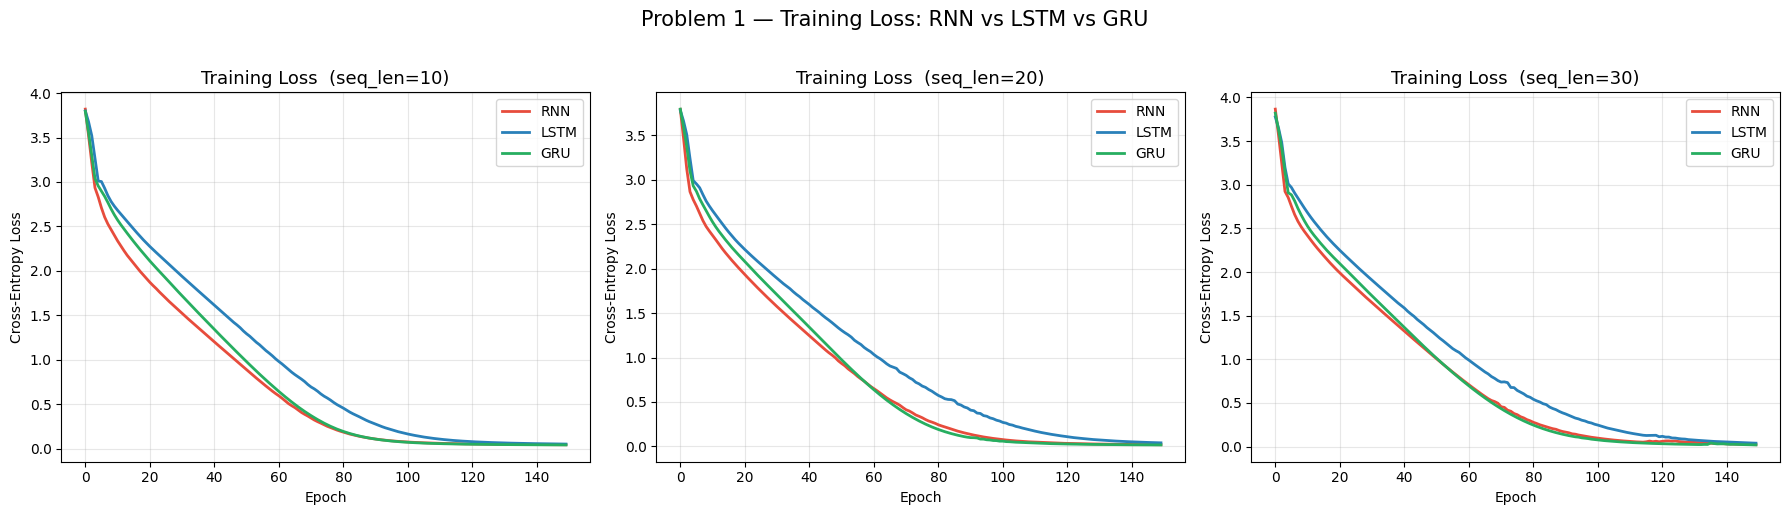

Saved → p1_training_loss.png


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)
colors = {"RNN": "#e74c3c", "LSTM": "#2980b9", "GRU": "#27ae60"}

for ax, seq_len in zip(axes, SEQ_LENGTHS):
    for r in all_results:
        if r["seq_len"] == seq_len:
            ax.plot(r["train_losses"],
                    label=r["rnn_type"],
                    color=colors[r["rnn_type"]], linewidth=2)
    ax.set_title(f"Training Loss  (seq_len={seq_len})", fontsize=13)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Cross-Entropy Loss")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle("Problem 1 — Training Loss: RNN vs LSTM vs GRU", fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig("p1_training_loss.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → p1_training_loss.png")


## Cell 9 — Validation Accuracy Curves

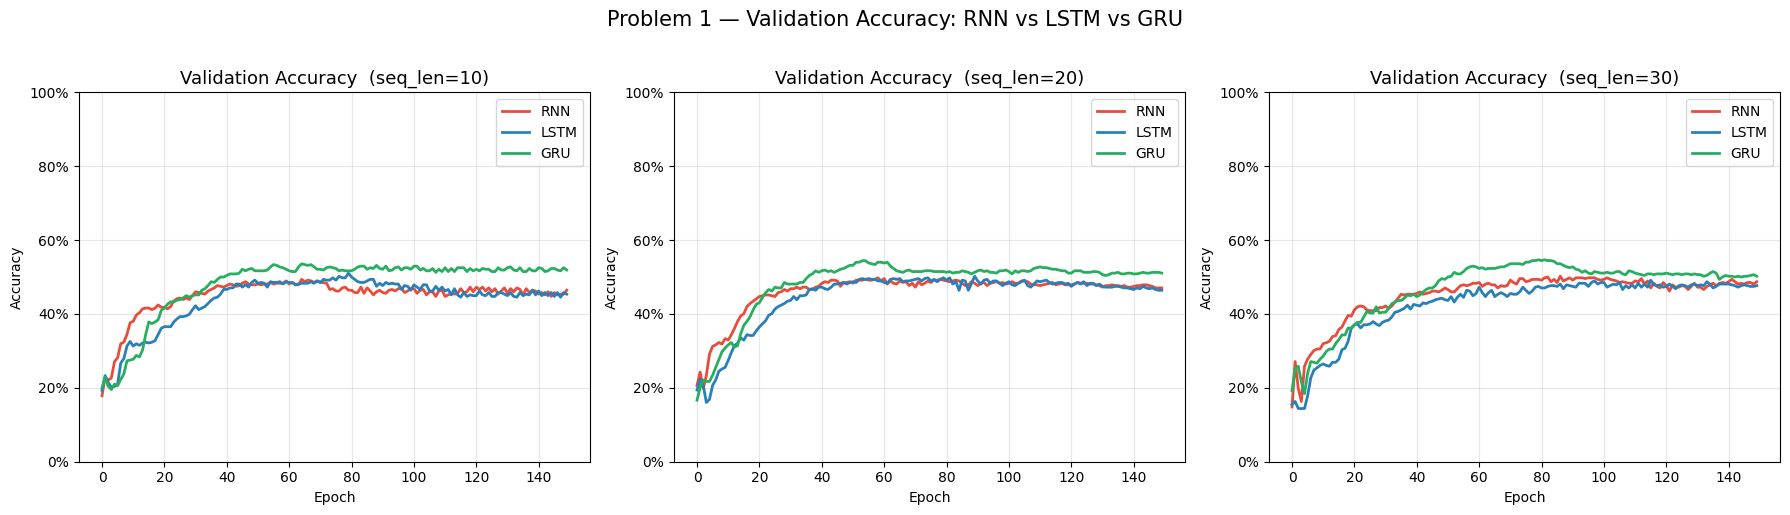

Saved → p1_val_accuracy.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

for ax, seq_len in zip(axes, SEQ_LENGTHS):
    for r in all_results:
        if r["seq_len"] == seq_len:
            ax.plot(r["val_accuracies"],
                    label=r["rnn_type"],
                    color=colors[r["rnn_type"]], linewidth=2)
    ax.set_title(f"Validation Accuracy  (seq_len={seq_len})", fontsize=13)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy")
    ax.set_ylim(0, 1)
    ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1))
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle("Problem 1 — Validation Accuracy: RNN vs LSTM vs GRU", fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig("p1_val_accuracy.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → p1_val_accuracy.png")


## Cell 10 — Bar Chart Comparisons (Training Time & Model Size)

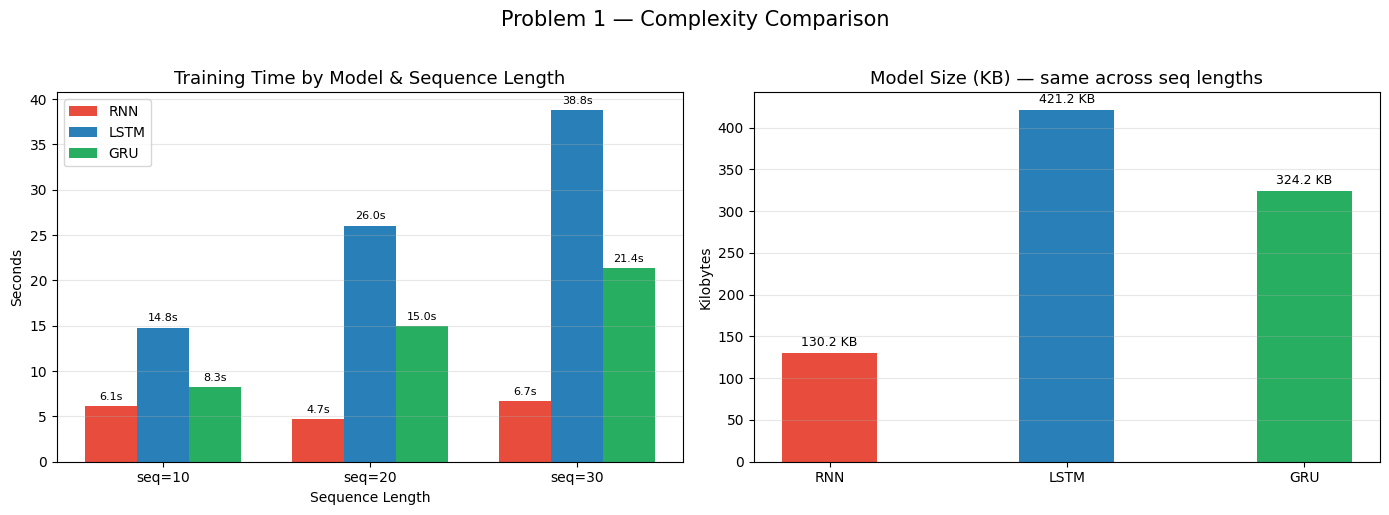

Saved → p1_complexity.png


In [ ]:
import numpy as np

x      = np.arange(len(SEQ_LENGTHS))
width  = 0.25
color_list = [colors[m] for m in RNN_TYPES]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#  Training Time 
ax = axes[0]
for i, rnn_type in enumerate(RNN_TYPES):
    times = [r["train_time_s"] for r in all_results if r["rnn_type"] == rnn_type]
    bars = ax.bar(x + i * width, times, width, label=rnn_type, color=color_list[i])
    ax.bar_label(bars, fmt="%.1fs", padding=3, fontsize=8)
ax.set_title("Training Time by Model & Sequence Length", fontsize=13)
ax.set_xlabel("Sequence Length")
ax.set_ylabel("Seconds")
ax.set_xticks(x + width)
ax.set_xticklabels([f"seq={s}" for s in SEQ_LENGTHS])
ax.legend()
ax.grid(axis="y", alpha=0.3)

#  Model Size 
ax = axes[1]
# Model size is same across seq lengths for same model type; show once per model
model_sizes = {rnn_type: next(r["model_size_kb"] for r in all_results
                              if r["rnn_type"] == rnn_type)
               for rnn_type in RNN_TYPES}
bars = ax.bar(RNN_TYPES,
              [model_sizes[m] for m in RNN_TYPES],
              color=color_list, width=0.4)
ax.bar_label(bars, fmt="%.1f KB", padding=3, fontsize=9)
ax.set_title("Model Size (KB) — same across seq lengths", fontsize=13)
ax.set_ylabel("Kilobytes")
ax.grid(axis="y", alpha=0.3)

plt.suptitle("Problem 1 — Complexity Comparison", fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig("p1_complexity.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → p1_complexity.png")


## Cell 11 — Final Validation Accuracy Comparison

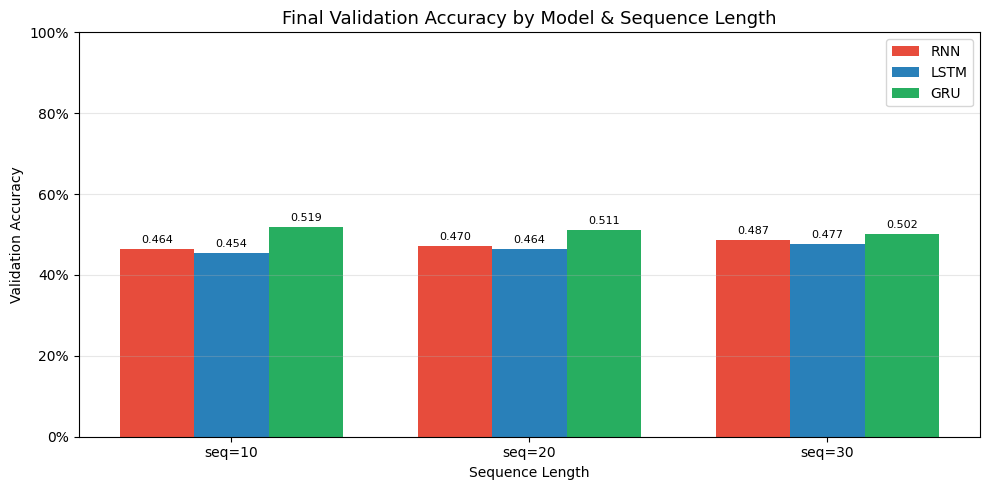

Saved → p1_final_accuracy.png


In [11]:
fig, ax = plt.subplots(figsize=(10, 5))

for i, rnn_type in enumerate(RNN_TYPES):
    accs = [r["final_acc"] for r in all_results if r["rnn_type"] == rnn_type]
    bars = ax.bar(x + i * width, accs, width, label=rnn_type, color=color_list[i])
    ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=8)

ax.set_title("Final Validation Accuracy by Model & Sequence Length", fontsize=13)
ax.set_xlabel("Sequence Length")
ax.set_ylabel("Validation Accuracy")
ax.set_xticks(x + width)
ax.set_xticklabels([f"seq={s}" for s in SEQ_LENGTHS])
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1))
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("p1_final_accuracy.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → p1_final_accuracy.png")
